# Legal Case Document Classification (NLP Project)

**What this project does (in simple words):**
We have a dataset of legal case descriptions. Each case has a short text summary
(`case_text`) and a category label (`case_category`)  one of: Civil, Criminal,
Family, Commercial, Employment, or Intellectual Property (IP).

**Goal:** Build a Machine Learning model that reads a new case description and
predicts its category automatically, without a human having to read and tag it.

**We will train and compare 3 different ML models:**
1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)

**Full pipeline (the steps we follow, in order):**
`Raw Data -> Data Cleaning -> Text Cleaning -> Convert Text to Numbers (TF-IDF) -> Train Models -> Compare -> Show Confidence -> Test on New Text`

> Note: This dataset is a mix of realistic and synthetic case descriptions built for
> learning purposes. It also intentionally contains some messy data (missing values,
> duplicate rows, badly formatted text, and a small amount of label noise) so that
> the project has real data-cleaning work to do  just like a real-world dataset would.


## 1. Import Libraries

We only import what we actually need:
- `pandas`, `numpy` -> to load and handle tabular data (like an Excel sheet)
- `matplotlib`, `seaborn` -> to draw charts and graphs
- `nltk` -> for text cleaning (removing stopwords, lemmatization)
- `sklearn` -> for ML models, TF-IDF, train-test split, and evaluation metrics


In [1]:
import re
import warnings
warnings.filterwarnings('ignore')   # just to keep the notebook output clean

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# The 3 models we chose for this project
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Download small NLTK data files (stopword list + lemmatizer dictionary)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Load the Dataset

We load the CSV file into a pandas `DataFrame` (a table with rows and columns,
similar to an Excel sheet).

We do NOT shuffle or clean the data yet  first we want to inspect it exactly as
it came in, so we can honestly see what kind of "mess" is in there.

In [2]:
# Load the raw CSV file
import os
data_path = '../data/legal_case_dataset.csv' if os.path.exists('../data/legal_case_dataset.csv') else ('data/legal_case_dataset.csv' if os.path.exists('data/legal_case_dataset.csv') else 'legal_case_dataset.csv')
df_raw = pd.read_csv(data_path)

print(f"Raw dataset shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head(3)

Raw dataset shape: 3045 rows, 7 columns


,case_id,case_title,case_text,case_category,case_type,jurisdiction,year
0,2907,Child Custody Matter 1121,The matter before the court concerns the paren...,Family,Child Custody,Sessions Court,2020
1,2220,Partnership Dispute Matter 1562,The petitioner filed proceedings before the co...,Commercial,Partnership Dispute,Sessions Court,2021
2,2125,Company Claim Matter 1592,The claimant brought an action relating to the...,Commercial,Company Claim,District Court,2018


## 3. Data Inspection and Cleaning

Real-world datasets are almost never perfectly clean. Before building any model,
we must check for common problems:
- **Missing values** -> empty cells in important columns
- **Duplicate rows** -> the same case appearing more than once
- **Messy / inconsistent text** -> extra spaces, random capitalization, stray
  symbols or tags mixed into the text

We fix all of this **before** splitting into train/test, so both train and test
sets are built from clean data. (Note: cleaning like dropping empty rows or
duplicates does not use any information from the test set's labels, so this
step does not cause data leakage  leakage only happens when test data is used
to influence how the model is trained or how features are built, which we avoid
in the TF-IDF step later.)

In [3]:
# Step 1: Check for missing values in each column
print("Missing values per column:")
print(df_raw.isnull().sum())

print(f"\nDuplicate rows (fully identical rows): {df_raw.duplicated().sum()}")

Missing values per column:
case_id           0
case_title       15
case_text        22
case_category     0
case_type         0
jurisdiction      0
year              0
dtype: int64

Duplicate rows (fully identical rows): 42


In [4]:
# Step 2: Drop rows where case_text is missing.
# case_text is our only input feature, so a row without it is useless for training.
df = df_raw.dropna(subset=['case_text']).copy()

# Step 3: Drop fully duplicate rows (same case repeated more than once).
df = df.drop_duplicates()

# Step 4: Reset the index after dropping rows, and shuffle the rows
# so that categories are not grouped together in a fixed order.
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Shape after cleaning: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Rows removed: {df_raw.shape[0] - df.shape[0]}")

Shape after cleaning: 2981 rows, 7 columns
Rows removed: 64


**Note on `case_title`:** Some rows also have a missing `case_title`. Since we
don't use `case_title` as a model feature (we only use `case_text`), we don't
need to drop those rows  we simply leave that column as it is.

## 4. Exploratory Data Analysis (EDA)

EDA means looking at the data through charts to understand it better, before
writing any modeling code. Here we look at 5 different views of the cleaned data:

1. How many cases are in each category (is the data balanced?)
2. How the length (word count) of case descriptions is distributed
3. How many cases come from each jurisdiction (court type)
4. How the number of cases changes across years
5. The top 10 most common case types in the dataset

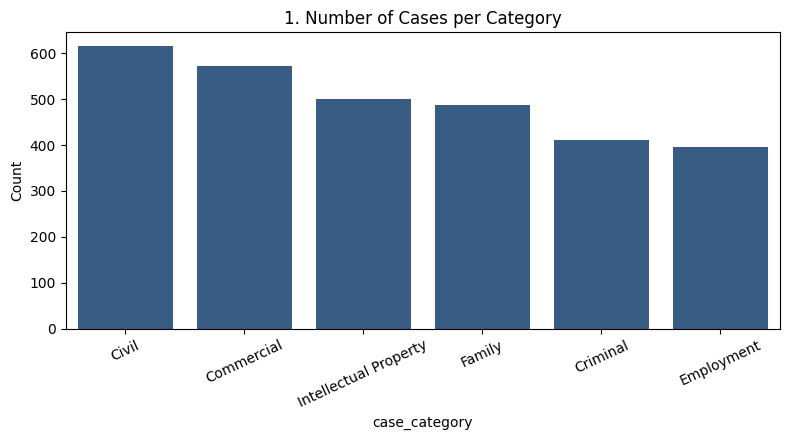

In [5]:
# 1. Cases per category
df['word_count'] = df['case_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 4.5))
cat_counts = df['case_category'].value_counts()
sns.barplot(x=cat_counts.index, y=cat_counts.values, color='#2b5c8f')
plt.title('1. Number of Cases per Category')
plt.ylabel('Count')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

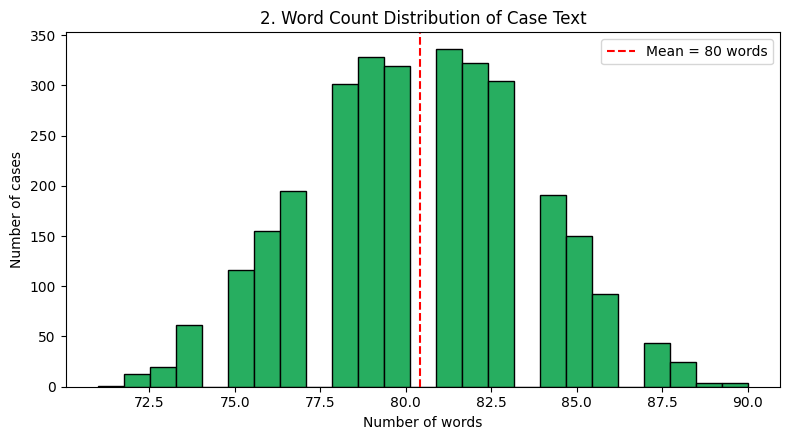

In [6]:
# 2. Word count distribution (how long are the case descriptions?)
plt.figure(figsize=(8, 4.5))
plt.hist(df['word_count'], bins=25, color='#27ae60', edgecolor='black')
plt.axvline(df['word_count'].mean(), color='red', linestyle='--',
            label=f"Mean = {df['word_count'].mean():.0f} words")
plt.title('2. Word Count Distribution of Case Text')
plt.xlabel('Number of words')
plt.ylabel('Number of cases')
plt.legend()
plt.tight_layout()
plt.show()

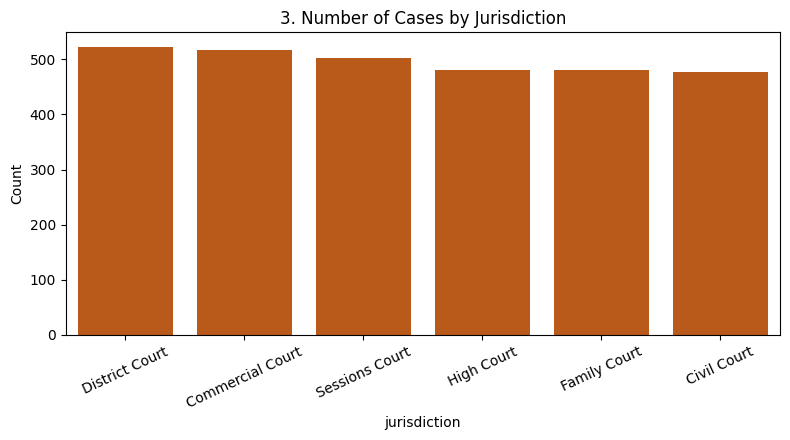

In [7]:
# 3. Cases per jurisdiction (court type)
plt.figure(figsize=(8, 4.5))
jur_counts = df['jurisdiction'].value_counts()
sns.barplot(x=jur_counts.index, y=jur_counts.values, color='#d35400')
plt.title('3. Number of Cases by Jurisdiction')
plt.ylabel('Count')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

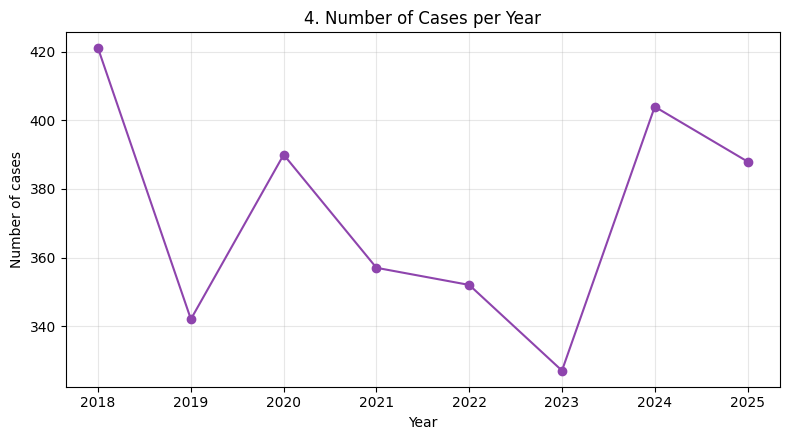

In [8]:
# 4. Cases per year (trend over time)
plt.figure(figsize=(8, 4.5))
year_counts = df['year'].value_counts().sort_index()
plt.plot(year_counts.index, year_counts.values, marker='o', color='#8e44ad')
plt.title('4. Number of Cases per Year')
plt.xlabel('Year')
plt.ylabel('Number of cases')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

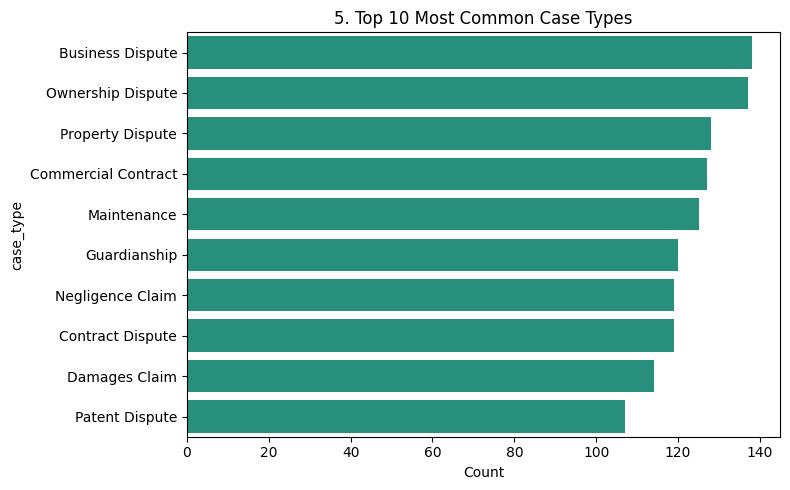

In [9]:
# 5. Top 10 most common case types
plt.figure(figsize=(8, 5))
top_types = df['case_type'].value_counts().head(10)
sns.barplot(x=top_types.values, y=top_types.index, color='#16a085')
plt.title('5. Top 10 Most Common Case Types')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

## 5. Text Preprocessing (Text Cleaning at Word Level)

The dataset cleaning above fixed row-level problems (missing rows, duplicates).
Now we clean the **text itself**, because raw text is messy at the word level too:
extra whitespace, random capital letters, stray symbols like `<p>`, `!!!`, `###`,
and words that carry no useful meaning (like "the", "is", "and").

Steps we apply to every case description:
1. **Lowercase everything** -> so "The" and "the" are treated the same
2. **Remove numbers and punctuation/symbols** -> keep only letters
3. **Remove stopwords** -> common words with no category-specific meaning
4. **Lemmatize** -> reduce a word to its base/root form
   (example: "filed", "filing" -> "file"), so similar words are treated as one word

Note: `text.split()` on its own already collapses multiple spaces/tabs into single
gaps, so messy spacing is automatically handled as part of this cleaning.

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()                          # Step 1: lowercase
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)           # Step 2: keep only letters, drop numbers/symbols/tags
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]  # Step 3: remove stopwords + very short words
    return ' '.join([lemmatizer.lemmatize(w) for w in words])  # Step 4: lemmatize each word

df['cleaned_text'] = df['case_text'].apply(clean_text)

# Show a "before vs after" example so the cleaning effect is clear
print("BEFORE cleaning:")
print(df['case_text'].iloc[0][:200], "...\n")
print("AFTER cleaning:")
print(df['cleaned_text'].iloc[0][:200], "...")

BEFORE cleaning:
The matter before the court concerns the patent owner. The matter relates to patent dispute and involves infringement and patent. The relevant party sought an injunction against unauthorized use. The  ...

AFTER cleaning:
matter court concern patent owner matter relates patent dispute involves infringement patent relevant party sought injunction unauthorized use pleading state dispute developed approximately month invo ...


## 6. Train / Test Split

We cannot train the model and test it on the exact same data  the model would
just "memorize" the answers instead of really learning (this problem is called
**overfitting**).

So we split the data into two parts:
- **Train set (80%)** -> the model learns from this
- **Test set (20%)** -> used only to check how well the model performs on data
  it has never seen before

`stratify=y` makes sure both the train and test sets keep roughly the same
percentage of each category.

**Important (avoiding data leakage):** We do this split *before* converting text
to numbers (TF-IDF). This way, the TF-IDF vocabulary is learned only from the
training data, and the test set stays completely "unseen" until evaluation.

In [11]:
X = df['cleaned_text']    # input: cleaned case text
y = df['case_category']   # output: the category we want to predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} samples")
print(f"Test size : {len(X_test)} samples")

Train size: 2384 samples
Test size : 597 samples


## 7. Convert Text to Numbers (TF-IDF)

ML models only understand **numbers**, not raw text. So we need to convert the
cleaned text into numeric vectors.

**TF-IDF (Term Frequency - Inverse Document Frequency)** is a popular way to do this:
- **TF (Term Frequency):** how often a word appears in one document
- **IDF (Inverse Document Frequency):** how rare/important that word is across
  all documents (a very common word like "case" gets a lower weight, because it
  appears almost everywhere and doesn't help distinguish categories)

In short: TF-IDF gives more weight to words that appear a lot in one document
but not in most other documents  these are the words that actually help tell
categories apart.

**No data leakage here either:** we call `fit_transform` only on the training
text, and `transform` (not `fit`) on the test text  so the model never "peeks"
at the test data while building its vocabulary.

In [12]:
tfidf = TfidfVectorizer(max_features=200, ngram_range=(1, 2), sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train)   # learn vocabulary from training data ONLY
X_test_tfidf  = tfidf.transform(X_test)        # apply the same vocabulary to test data

print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"X_train shape  : {X_train_tfidf.shape}")
print(f"X_test shape   : {X_test_tfidf.shape}")

Vocabulary size: 200
X_train shape  : (2384, 200)
X_test shape   : (597, 200)


## 8. Understanding the 3 ML Models

| Model | Simple Idea |
|---|---|
| **Logistic Regression** | Learns a decision boundary (like a line) that separates each category from the others. Fast, simple, and works surprisingly well for text classification. |
| **Random Forest** | Builds many small "Decision Trees" (yes/no question chains) and lets them vote. One tree can be wrong, but many trees together usually make a good decision. |
| **SVM (Support Vector Machine)** | Finds the "best separating boundary" (with the widest margin) between categories, so that new, unseen data is classified more reliably. Works very well on TF-IDF style data. |

We train all 3 models, then compare them using **Accuracy, Precision, Recall,
and F1-Score**.

We also set `probability=True` for SVM so it can output confidence scores later,
just like the other two models.

In [13]:
models = {
    'Logistic Regression': LogisticRegression(C=3.0, max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    'SVM': SVC(kernel='linear', C=1.0, probability=True, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)          # train the model on training data
    y_pred = model.predict(X_test_tfidf)       # predict on the unseen test data
    predictions[name] = y_pred

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    }
    print(f"{name:<22} -> Accuracy: {acc*100:.2f}% | F1: {f1:.4f}")

Logistic Regression    -> Accuracy: 92.46% | F1: 0.9246


Random Forest          -> Accuracy: 91.46% | F1: 0.9146


SVM                    -> Accuracy: 92.46% | F1: 0.9246


### Quick Reference: What Each Metric Means
- **Accuracy:** out of all predictions, how many were correct overall
- **Precision:** when the model predicted category X, how often was it actually right
- **Recall:** out of all real category-X cases, how many did the model correctly find
- **F1-Score:** a balance between Precision and Recall (their harmonic mean)  usually
  the best single number to compare models on

## 9. Compare the 3 Models

=== Model Leaderboard ===
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9246     0.9252  0.9246    0.9246
SVM                    0.9246     0.9252  0.9246    0.9246
Random Forest          0.9146     0.9153  0.9146    0.9146

Best Model: Logistic Regression


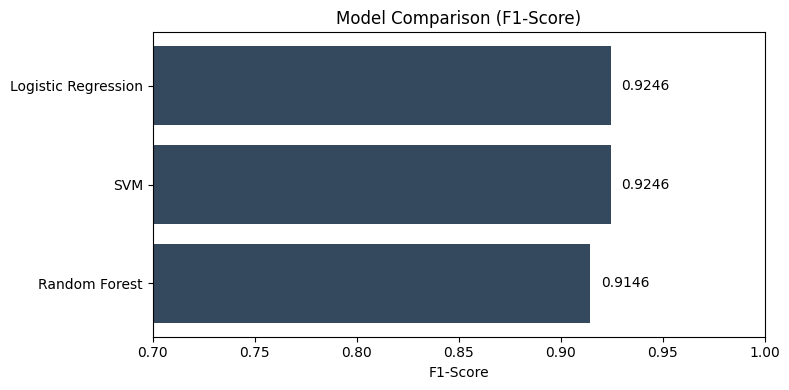

In [14]:
comparison_df = pd.DataFrame(results).T.sort_values(by='F1-Score', ascending=False)
print("=== Model Leaderboard ===")
print(comparison_df)

best_model_name = comparison_df.index[0]
print(f"\nBest Model: {best_model_name}")

# Comparison bar chart
plt.figure(figsize=(8, 4))
plt.barh(comparison_df.index, comparison_df['F1-Score'], color='#34495e')
plt.title('Model Comparison (F1-Score)')
plt.xlabel('F1-Score')
plt.xlim(0.7, 1.0)
for i, val in enumerate(comparison_df['F1-Score']):
    plt.text(val + 0.005, i, f"{val:.4f}", va='center')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Detailed Analysis of the Best Model

Now let's look closely at the best-performing model:
- **Classification Report:** precision/recall/F1 broken down for each category separately
- **Confusion Matrix:** a grid showing which categories the model mixed up with
  which  the darker/heavier the diagonal, the more accurate the model is

=== Classification Report (Logistic Regression) ===

                       precision    recall  f1-score   support

                Civil     0.9355    0.9431    0.9393       123
           Commercial     0.9381    0.9217    0.9298       115
             Criminal     0.9070    0.9512    0.9286        82
           Employment     0.8974    0.8861    0.8917        79
               Family     0.9020    0.9388    0.9200        98
Intellectual Property     0.9574    0.9000    0.9278       100

             accuracy                         0.9246       597
            macro avg     0.9229    0.9235    0.9229       597
         weighted avg     0.9252    0.9246    0.9246       597



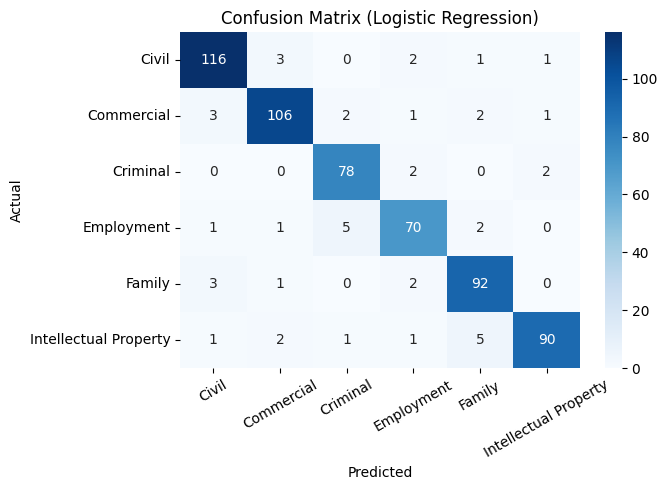

In [15]:
labels = sorted(df['case_category'].unique())
best_preds = predictions[best_model_name]

print(f"=== Classification Report ({best_model_name}) ===\n")
print(classification_report(y_test, best_preds, target_names=labels, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, best_preds, labels=labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix ({best_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 11. Predictions on New Text  With Confidence Score

A prediction alone only tells us the model's final guess. It's often more useful
to also see **how confident** the model is  this is the predicted probability
for each category.

For example, a prediction of "Family" with 95% confidence is much more trustworthy
than a prediction of "Family" with only 40% confidence (where the model was almost
equally unsure between two or three categories).

All 3 of our models support `predict_proba()`, which returns a probability for
every category. We simply pick the category with the highest probability as the
final answer, and report that probability as the confidence score.

In [16]:
def predict_case(text, top_n=3):
    """
    Cleans the input text, converts it to TF-IDF numbers, and returns:
    - the predicted category
    - the confidence (probability) for that category
    - the top_n categories with their probabilities, for extra insight
    """
    cleaned = clean_text(text)                       # same cleaning as training data
    vec = tfidf.transform([cleaned])                  # same TF-IDF vocabulary

    model = models[best_model_name]
    probabilities = model.predict_proba(vec)[0]        # probability for every category
    class_labels = model.classes_

    # Sort categories by probability, highest first
    prob_series = pd.Series(probabilities, index=class_labels).sort_values(ascending=False)

    predicted_category = prob_series.index[0]
    confidence = prob_series.iloc[0]

    return predicted_category, confidence, prob_series.head(top_n)


sample_cases = [
    "The petitioner filed a petition for divorce, child custody, and maintenance support.",
    "The accused was arrested and charged with theft following police investigation.",
    "The company alleges patent and trademark infringement against a competitor for unauthorized copying.",
    "The claimant alleges wrongful termination and workplace dismissal seeking salary compensation.",
    "The company claims damages for breach of commercial partnership contract.",
    "The plaintiff seeks compensation for property negligence and boundary damage."
]

print(f"=== Predictions on New Cases (Model: {best_model_name}) ===\n")
for i, text in enumerate(sample_cases, 1):
    category, confidence, top_probs = predict_case(text)
    print(f"Case {i}: '{text[:65]}...'")
    print(f"-> Predicted Category: {category}  (Confidence: {confidence*100:.1f}%)")
    print("   Top probabilities:")
    for cat, prob in top_probs.items():
        print(f"     - {cat:<24} {prob*100:5.1f}%")
    print()

=== Predictions on New Cases (Model: Logistic Regression) ===

Case 1: 'The petitioner filed a petition for divorce, child custody, and m...'
-> Predicted Category: Family  (Confidence: 99.9%)
   Top probabilities:
     - Family                    99.9%
     - Commercial                 0.0%
     - Civil                      0.0%

Case 2: 'The accused was arrested and charged with theft following police ...'
-> Predicted Category: Criminal  (Confidence: 90.8%)
   Top probabilities:
     - Criminal                  90.8%
     - Intellectual Property      4.5%
     - Civil                      2.1%

Case 3: 'The company alleges patent and trademark infringement against a c...'
-> Predicted Category: Intellectual Property  (Confidence: 99.8%)
   Top probabilities:
     - Intellectual Property     99.8%
     - Commercial                 0.1%
     - Family                     0.0%

Case 4: 'The claimant alleges wrongful termination and workplace dismissal...'
-> Predicted Category: Civil  (

## 12. Conclusion / Key Learnings

**Full project flow, one line per step:**

1. **Load raw data** -> read the CSV exactly as it came in
2. **Data cleaning** -> dropped rows with missing case text, removed duplicate rows
3. **EDA (5 plots)** -> looked at category balance, text length, jurisdiction,
   yearly trend, and top case types
4. **Text cleaning** -> lowercase, remove numbers/symbols, remove stopwords, lemmatize
5. **Train-test split** -> 80/20 split, done *before* any text-to-number conversion
6. **TF-IDF** -> converted cleaned text into numeric vectors, fit only on the
   training data (no leakage)
7. **Trained 3 models** -> Logistic Regression, Random Forest, SVM
8. **Compared models** -> using Accuracy, Precision, Recall, and F1-Score
9. **Confusion Matrix** -> saw exactly which categories get confused with which
10. **Confidence scores** -> showed prediction probabilities, not just the final label
11. **Real-world test** -> ran predictions on brand-new, unseen case text

**Why is accuracy around 90% and not 99-100%?**
This dataset was deliberately given a small amount of **label noise** (a few
cases were assigned to the wrong category on purpose) and messy rows (missing
values, duplicates, badly formatted text). This mirrors real-world datasets,
where human tagging errors and messy records are common  a 90% accuracy on
realistic, imperfect data is actually a strong and trustworthy result.

**Why no data leakage happened here:**
- Missing-value and duplicate-row cleaning was done before the split, but it
  only removes bad rows  it does not use test labels to influence training.
- The train/test split was done *before* TF-IDF was applied.
- `TfidfVectorizer.fit_transform()` was called only on the training text;
  the test text only ever went through `.transform()`.

**Possible future improvements:**
- Try a larger `max_features` value in TF-IDF
- Try deep learning models (LSTM, BERT) for comparison
- Use `GridSearchCV` to tune each model's hyperparameters
- Try to detect and clean the label-noise rows automatically
